In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam # Import optimizer
from scikeras.wrappers import KerasClassifier # Wrapper untuk Keras di Scikit-learn

In [2]:
df = pd.read_csv('features_selected/TVOC_selected_features.csv')
df

,TVOC_Skew,TVOC_Decay,TVOC_Kurtosis,Label
0,2.145402,0.181673,3.805084,butana
1,1.899005,0.201204,2.544621,butana
2,2.112537,0.130841,3.601863,butana
3,2.126913,0.170684,3.671346,butana
4,2.081987,0.149772,3.417740,butana
...,...,...,...,...
75,2.115171,0.165337,3.673264,butana
76,5.456874,0.663833,29.722503,spirtus
77,5.442858,0.812571,29.091908,spirtus
78,2.191213,0.168066,4.055420,butana


In [3]:
# Separate features (X) and target (y)
X = df.drop('Label', axis=1).values
y = df['Label'].values

# Encode the target variable (Label)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[0.04471949, 0.0612923 , 0.02226172],
       [0.        , 0.08484111, 0.        ],
       [0.03875463, 0.        , 0.01867253],
       [0.04136388, 0.04804108, 0.0198997 ],
       [0.03321014, 0.02282633, 0.01542063],
       [0.03836713, 0.05433586, 0.01793439],
       [0.01237104, 0.05541114, 0.00471311],
       [0.65123194, 0.72792134, 0.47600511],
       [0.01548756, 0.09911181, 0.00633471],
       [0.01078321, 0.07804691, 0.00373893],
       [0.71665486, 0.66012702, 0.55975855],
       [0.04270198, 0.03687055, 0.0197912 ],
       [0.64323047, 0.594754  , 0.49287176],
       [0.04713362, 0.04195516, 0.0232988 ],
       [0.93700814, 0.39218728, 0.89118807],
       [0.95661966, 0.39464301, 0.91213015],
       [0.66008752, 0.58585045, 0.51160007],
       [0.71854953, 0.67922322, 0.57093016],
       [0.91829918, 0.72152738, 0.8565727 ],
       [0.68403033, 0.62682147, 0.52978073],
       [0.02553546, 0.01933263, 0.01118713],
       [0.94248879, 0.87150295, 0.88528709],
       [0.

In [4]:
import tensorflow as tf

def create_model(lr, hidden_units,hidden_units1):
    model = Sequential()
    model.add(tf.keras.Input(shape=(X_scaled.shape[1],)))
    model.add(Dense(hidden_units, activation='relu'))
    model.add(Dense(hidden_units1, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'], )
    return model

# parameter
param_grid = {
    'model__lr': [0.001, 0.01],
    'model__hidden_units': [32],
    'model__hidden_units1': [16],
    'batch_size': [32],
    'epochs': [100, 120]
}

# keras clasifier
keras_model = KerasClassifier(model=create_model, verbose=0)

# cross validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Menggunakan 3 fold untuk contoh ini

# grid search
grid_search = GridSearchCV(
    estimator=keras_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1 #core cpu
)

# running
print("Memulai GridSearchCV...")
grid_search.fit(X_scaled, y_encoded)
print("GridSearchCV selesai.")

# coba print hasil
print("\n--- Hasil GridSearchCV ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best validation accuracy: {grid_search.best_score_:.4f}")

# best model
best_model = grid_search.best_estimator_

Memulai GridSearchCV...
GridSearchCV selesai.

--- Hasil GridSearchCV ---
Best parameters found: {'batch_size': 32, 'epochs': 100, 'model__hidden_units': 32, 'model__hidden_units1': 16, 'model__lr': 0.001}
Best validation accuracy: 1.0000


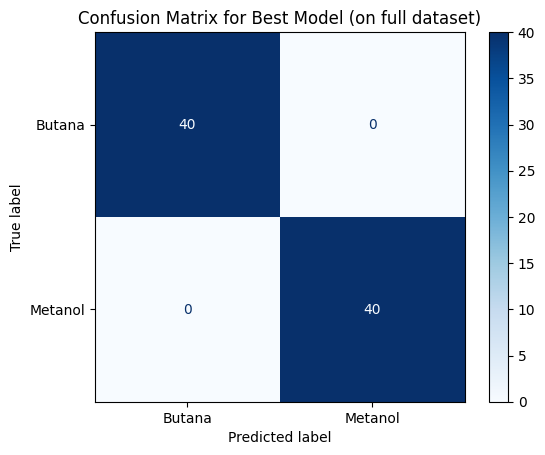


--- Classification Report (on full dataset) ---
              precision    recall  f1-score   support

      Butana       1.00      1.00      1.00        40
     Metanol       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Pastikan numpy diimpor

# Asumsi X_scaled dan y sudah ada dari langkah sebelumnya
# Asumsi best_model = grid_search.best_estimator_ sudah didefinisikan

# 1. Lakukan prediksi menggunakan model terbaik
# best_model.predict mengembalikan probabilitas, perlu diubah ke kelas biner (0 atau 1)
y_pred_prob = best_model.predict(X_scaled)

y_pred_prob

# Konversi probabilitas menjadi label kelas biner (0 atau 1)
# Untuk klasifikasi biner dengan sigmoid, ambang batas umum adalah 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Hitung Confusion Matrix
cm = confusion_matrix(y_encoded, y_pred)

# 3. Tampilkan Confusion Matrix
# Dapatkan nama kelas (jika tidak ada, gunakan 0 dan 1)
class_names = ['Butana', 'Metanol'] # Sesuaikan ini jika Anda memiliki nama kelas sebenarnya

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best Model (on full dataset)')
plt.show()

# Opsional: Tampilkan metrik klasifikasi lainnya
from sklearn.metrics import classification_report
print("\n--- Classification Report (on full dataset) ---")
print(classification_report(y_encoded, y_pred, target_names=class_names))

Melatih model terakhir dengan hyperparameter terbaik (Epochs: 100, Batch Size: 32)...
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4500 - loss: 0.6860
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6756
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5125 - loss: 0.6645
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5500 - loss: 0.6533
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6625 - loss: 0.6414
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8500 - loss: 0.6294
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9625 - loss: 0.6173
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9750 - loss: 0.6059
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9875 - loss: 0.5932
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.5822
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - l

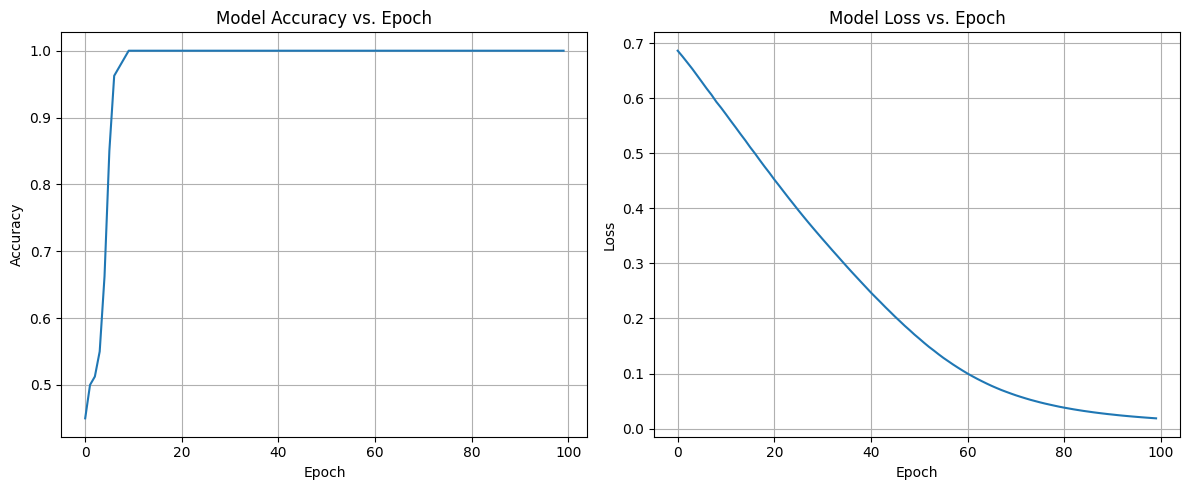

In [6]:
# Extract best parameters from grid_search
best_params = grid_search.best_params_
best_lr = best_params['model__lr']
best_hidden_units = best_params['model__hidden_units']
best_hidden_units1 = best_params['model__hidden_units1']
best_batch_size = best_params['batch_size']
best_epochs = best_params['epochs']

# Create a new model instance with the best parameters
# This ensures we get a fresh training history
final_model = create_model(
    lr=best_lr,
    hidden_units=best_hidden_units,
    hidden_units1=best_hidden_units1
)

# Train the final model on the full data, capturing the history
print(f"Melatih model terakhir dengan hyperparameter terbaik (Epochs: {best_epochs}, Batch Size: {best_batch_size})...")
history = final_model.fit(
    X_scaled, y_encoded,
    epochs=best_epochs,
    batch_size=best_batch_size,
    verbose=1 # Set verbose to 1 to see training progress and capture history
)
print("Pelatihan model terakhir selesai.")

# Plot Akurasi vs Epoch
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy vs. Epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent overlap

# Plot Fungsi Loss vs Epoch
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.title('Model Loss vs. Epoch')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent overlap

plt.show() # Display the plots